# Mole Classifier:
This notebook trains a simple image classifier using Keras to tell the difference between benign moles and melanoma.


## Step 0: Install Neural Net Libraries

In [ ]:
!pip install tensorflow
!pip install keras

3 channel Terms of Service accepted



PackageNotInstalledError: Package is not installed in prefix.
  prefix: C:\Users\ecarter\AppData\Local\anaconda3
  package name: tensorflow




### Don't forget to restart your kernal at this point.

## Step 1: Import Libraries

In [2]:
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import os
import numpy as np

## Step 2: Load the Images

Keras can read images directly from folders. Each subfolder name becomes the label ("benign" or "malignant").

We resize all images to 64×64 pixels so they are all the same size.

In [3]:
IMAGE_SIZE = (64, 64)   # resize all images to 64x64 pixels
BATCH_SIZE = 16         # process 16 images at a time

# Class names based on your directory structure
CLASS_NAMES = ["NonDemented", "VeryMildDemented", "MildDemented", "ModerateDemented"]

def load_all_image_paths_and_labels(base_path):
    """Walk through combined_images subdirectories and collect paths + labels."""
    image_paths = []
    labels = []

    for label_idx, class_name in enumerate(CLASS_NAMES):
        class_dir = os.path.join(base_path, class_name)
        if not os.path.isdir(class_dir):
            print(f"Warning: Directory not found: {class_dir}")
            continue

        for fname in os.listdir(class_dir):
            if fname.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".gif")):
                image_paths.append(os.path.join(class_dir, fname))
                labels.append(label_idx)

    return np.array(image_paths), np.array(labels)

def parse_image(path, label):
    """Read and preprocess a single image."""
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, IMAGE_SIZE)
    image = tf.cast(image, tf.float32) / 255.0  # normalize to [0, 1]
    return image, label

def make_dataset(image_paths, labels, shuffle=False):
    """Create a tf.data.Dataset from file paths and labels."""
    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(image_paths), seed=42)
    dataset = dataset.map(parse_image, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

# --- Load all paths and labels ---
all_paths, all_labels = load_all_image_paths_and_labels("combined_images")

print(f"Total images found: {len(all_paths)}")
for idx, name in enumerate(CLASS_NAMES):
    print(f"  {name}: {np.sum(all_labels == idx)} images")

# --- Train/test split (80/20, stratified) ---
train_paths, test_paths, train_labels, test_labels = train_test_split(
    all_paths, all_labels,
    test_size=0.2,
    random_state=42,
    stratify=all_labels  # preserve class proportions in both splits
)

print(f"\nTrain size: {len(train_paths)} | Test size: {len(test_paths)}")

# --- Build datasets ---
train_data = make_dataset(train_paths, train_labels, shuffle=True)
test_data = make_dataset(test_paths,  test_labels,  shuffle=False)

# Print class names to match original usage
print("Classes:", CLASS_NAMES)

Total images found: 44000
  NonDemented: 12800 images
  VeryMildDemented: 11200 images
  MildDemented: 10000 images
  ModerateDemented: 10000 images

Train size: 35200 | Test size: 8800
Classes: ['NonDemented', 'VeryMildDemented', 'MildDemented', 'ModerateDemented']


## Step 3: Preview Some Images

Let's look at a few images so we know the data loaded correctly.

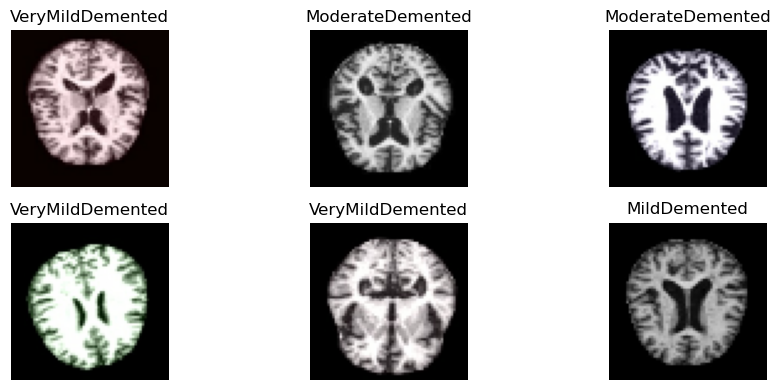

In [4]:
def show_sample_images(dataset, class_names=CLASS_NAMES):
    images, labels = next(iter(dataset))  # grab the first batch

    plt.figure(figsize=(10, 4))
    for i in range(6):
        plt.subplot(2, 3, i + 1)
        plt.imshow(images[i].numpy())
        label_index = int(labels[i].numpy())
        plt.title(class_names[label_index])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_sample_images(train_data)

## Step 5: Build the Model

Our neural network has three parts:
1. **Convolutional layers** — detect shapes and textures in the image
2. **Flatten** — turn the 2D feature map into a 1D list
3. **Dense layers** — make the final benign/melanoma decision

In [5]:
def build_model():
    model = keras.Sequential([
        # --- Feature detection ---
        keras.layers.Conv2D(16, (3, 3), activation="relu", input_shape=(64, 64, 3)),
        keras.layers.MaxPooling2D(),

        keras.layers.Conv2D(32, (3, 3), activation="relu"),
        keras.layers.MaxPooling2D(),

        # --- Decision making ---
        keras.layers.Flatten(),
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dense(4, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

model = build_model()
model.summary()

c:\Users\ecarter\AppData\Local\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       401,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 406,820 (1.55 MB)

 Trainable params: 406,820 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

## Step 6: Train the Model

We train for **5 epochs** (5 passes through the training data). This keeps training fast while still showing the model learning.

In [6]:
EPOCHS = 10

history = model.fit(
    train_data,
    epochs=EPOCHS,
    validation_data=test_data
)

Epoch 1/10
2200/2200 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - accuracy: 0.6917 - loss: 0.7009 - val_accuracy: 0.7882 - val_loss: 0.5158
Epoch 2/10
2200/2200 ━━━━━━━━━━━━━━━━━━━━ 35s 16ms/step - accuracy: 0.8451 - loss: 0.3798 - val_accuracy: 0.8486 - val_loss: 0.3745
Epoch 3/10
2200/2200 ━━━━━━━━━━━━━━━━━━━━ 54s 25ms/step - accuracy: 0.8987 - loss: 0.2507 - val_accuracy: 0.8817 - val_loss: 0.3036
Epoch 4/10
2200/2200 ━━━━━━━━━━━━━━━━━━━━ 50s 23ms/step - accuracy: 0.9263 - loss: 0.1870 - val_accuracy: 0.8944 - val_loss: 0.2854
Epoch 5/10
2200/2200 ━━━━━━━━━━━━━━━━━━━━ 35s 16ms/step - accuracy: 0.9419 - loss: 0.1466 - val_accuracy: 0.8933 - val_loss: 0.2898
Epoch 6/10
2200/2200 ━━━━━━━━━━━━━━━━━━━━ 35s 16ms/step - accuracy: 0.9518 - loss: 0.1193 - val_accuracy: 0.9032 - val_loss: 0.2787
Epoch 7/10
2200/2200 ━━━━━━━━━━━━━━━━━━━━ 35s 16ms/step - accuracy: 0.9635 - loss: 0.0945 - val_accuracy: 0.9032 - val_loss: 0.3276
Epoch 8/10
2200/2200 ━━━━━━━━━━━━━━━━━━━━ 35s 16ms/step - accuracy: 0.9686 -

## Step 7: Plot Training Results

Let's see how accuracy and loss changed over each epoch.

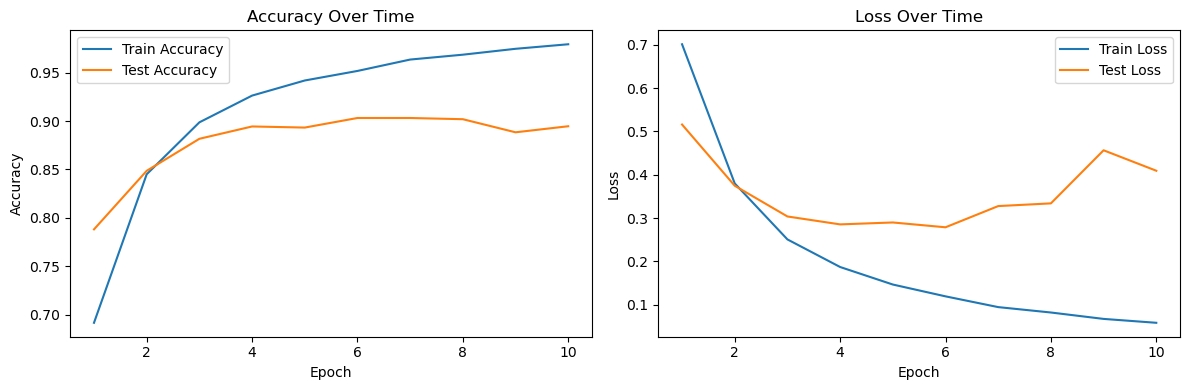

In [7]:
def plot_training(history):
    epochs = range(1, len(history.history["accuracy"]) + 1)

    plt.figure(figsize=(12, 4))

    # Accuracy plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history.history["accuracy"],     label="Train Accuracy")
    plt.plot(epochs, history.history["val_accuracy"], label="Test Accuracy")
    plt.title("Accuracy Over Time")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    # Loss plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history.history["loss"],     label="Train Loss")
    plt.plot(epochs, history.history["val_loss"], label="Test Loss")
    plt.title("Loss Over Time")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_training(history)

## Step 8: Evaluate on the Test Set

In [8]:
def evaluate_model(model, test_data):
    loss, accuracy = model.evaluate(test_data)
    print(f"Test Loss:     {loss:.4f}")
    print(f"Test Accuracy: {accuracy:.2%}")

evaluate_model(model, test_data)

550/550 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.8947 - loss: 0.4092
Test Loss:     0.4092
Test Accuracy: 89.47%


## Step 9: Predict on Individual Images

Let's look at a few test images and see what the model predicts.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step


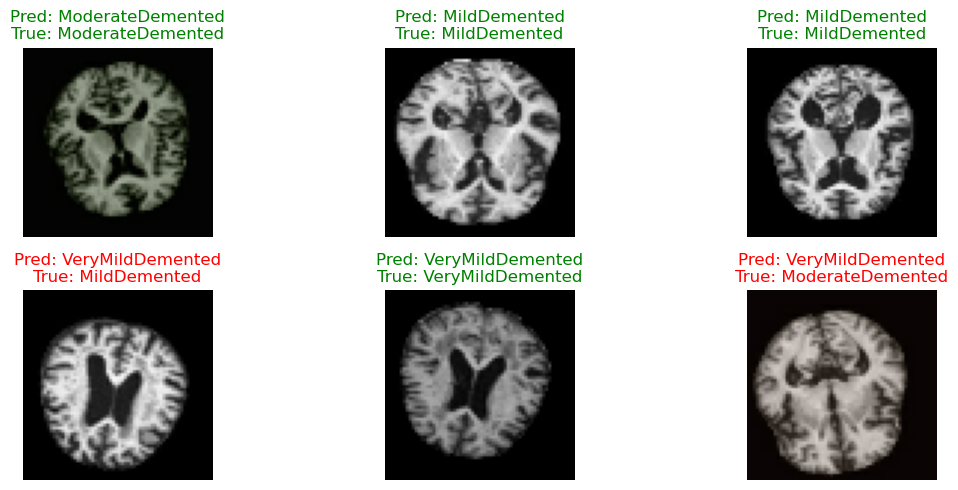

In [9]:
# Define class_names manually
class_names = ["NonDemented", "VeryMildDemented", "MildDemented", "ModerateDemented"]

def show_predictions(model, dataset, class_names, num_images=6):
    images, true_labels = next(iter(dataset))  # grab one batch

    predictions = model.predict(images)

    plt.figure(figsize=(12, 5))
    for i in range(num_images):
        plt.subplot(2, 3, i + 1)
        plt.imshow(images[i].numpy())

        predicted_index = int(np.argmax(predictions[i]))
        true_index = int(true_labels[i].numpy())

        predicted_label = class_names[predicted_index]
        true_label = class_names[true_index]

        color = "green" if predicted_index == true_index else "red"
        plt.title(f"Pred: {predicted_label}\nTrue: {true_label}", color=color)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_predictions(model, test_data, class_names)

In [10]:
!pip install opencv-python --break-system-packages

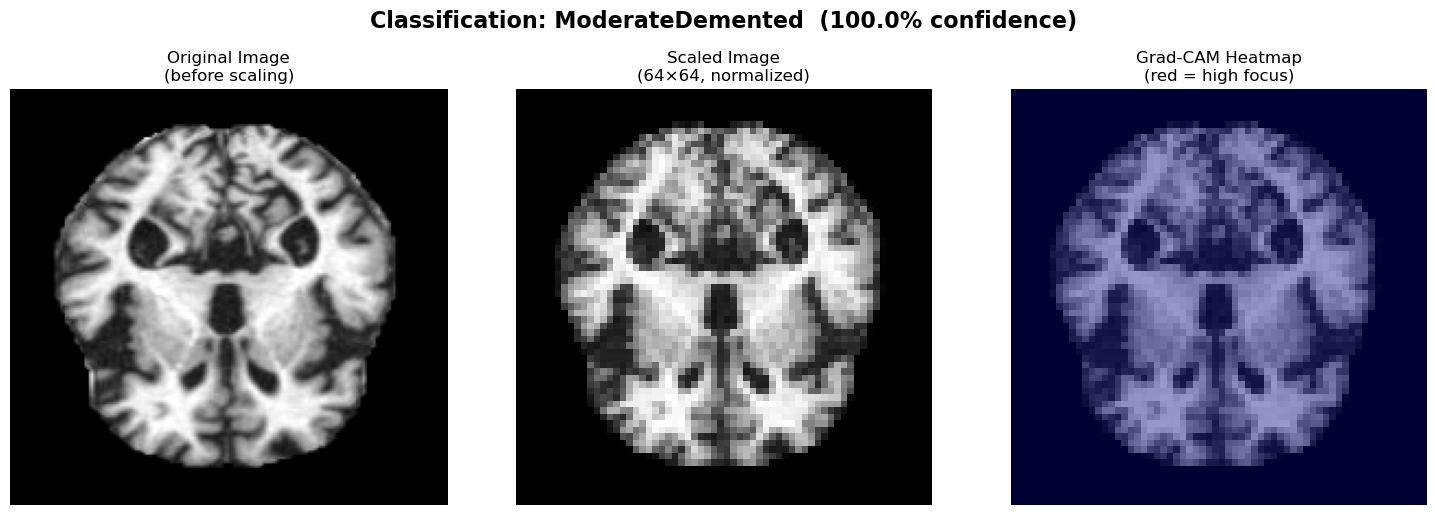


  Model Classification: ModerateDemented
  Confidence:           100.0%

All class probabilities:
  NonDemented            0.0%  
  VeryMildDemented       0.0%  
  MildDemented           0.0%  
  ModerateDemented     100.0%  ██████████████████████████████


In [13]:
# ============================================================
# GRAD-CAM IMAGE CLASSIFIER WITH HEATMAP VISUALIZATION
# ============================================================

import cv2

model = tf.keras.models.load_model("ethan_cnn_1.keras")

def load_original_image(filepath):
    """Load the raw image before any scaling/modification."""
    img_bgr = cv2.imread(filepath)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    return img_rgb

def preprocess_image_for_model(filepath):
    """Load and preprocess image to match model input (64x64, normalized)."""
    image = tf.io.read_file(filepath)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, IMAGE_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    return image  # shape: (64, 64, 3)

def compute_gradcam(model, img_tensor, class_idx):
    # Find the last Conv2D layer
    last_conv_layer = None
    for layer in model.layers:
        if isinstance(layer, keras.layers.Conv2D):
            last_conv_layer = layer

    if last_conv_layer is None:
        raise ValueError("No Conv2D layer found in model.")

    # Build a partial model up to the last conv layer
    conv_model = keras.Sequential(model.layers[:model.layers.index(last_conv_layer) + 1])
    classifier_layers = model.layers[model.layers.index(last_conv_layer) + 1:]

    img_batch = tf.expand_dims(img_tensor, axis=0)  # (1, 64, 64, 3)

    with tf.GradientTape() as tape:
        conv_outputs = conv_model(img_batch)
        tape.watch(conv_outputs)
        x = conv_outputs
        for layer in classifier_layers:
            x = layer(x)
        loss = x[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)         # (1, H, W, C)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))  # (C,)

    conv_outputs = conv_outputs[0]                    # (H, W, C)
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]  # (H, W, 1)
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.nn.relu(heatmap)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def overlay_heatmap_on_image(scaled_img_np, heatmap):
    """
    Resize heatmap to match the scaled image and overlay as a colored heatmap.
    scaled_img_np: numpy array, float32, shape (64, 64, 3), values in [0, 1]
    """
    h, w = scaled_img_np.shape[:2]

    # Resize heatmap to image size
    heatmap_resized = cv2.resize(heatmap, (w, h))

    # Apply colormap (JET: blue=low, red=high)
    heatmap_colored = cv2.applyColorMap(
        np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET
    )
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    heatmap_colored = heatmap_colored.astype(np.float32) / 255.0

    # Blend: 60% original image + 40% heatmap
    overlaid = 0.6 * scaled_img_np + 0.4 * heatmap_colored
    overlaid = np.clip(overlaid, 0, 1)
    return overlaid

def classify_and_visualize(model, filepath, class_names=CLASS_NAMES):
    """
    Full pipeline:
      1. Load original image (before any scaling)
      2. Preprocess (scale to 64x64, normalize)
      3. Run model prediction + Grad-CAM
      4. Display: original | scaled | scaled + heatmap | classification label
    """
    # --- 1. Original image ---
    original_img = load_original_image(filepath)

    # --- 2. Scaled/preprocessed image ---
    scaled_img = preprocess_image_for_model(filepath)       # tf.Tensor (64, 64, 3)
    scaled_img_np = scaled_img.numpy()                      # numpy (64, 64, 3)

    # --- 3. Predict ---
    img_batch = tf.expand_dims(scaled_img, axis=0)          # (1, 64, 64, 3)
    predictions = model.predict(img_batch, verbose=0)       # (1, 4)
    predicted_idx = int(np.argmax(predictions[0]))
    predicted_label = class_names[predicted_idx]
    confidence = float(predictions[0][predicted_idx]) * 100

    # --- 4. Grad-CAM heatmap ---
    heatmap = compute_gradcam(model, scaled_img, predicted_idx)
    overlaid = overlay_heatmap_on_image(scaled_img_np, heatmap)

    # --- 5. Plot all three images ---
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(
        f"Classification: {predicted_label}  ({confidence:.1f}% confidence)",
        fontsize=16, fontweight="bold", y=1.02
    )

    axes[0].imshow(original_img)
    axes[0].set_title("Original Image\n(before scaling)", fontsize=12)
    axes[0].axis("off")

    axes[1].imshow(scaled_img_np)
    axes[1].set_title(f"Scaled Image\n({IMAGE_SIZE[0]}×{IMAGE_SIZE[1]}, normalized)", fontsize=12)
    axes[1].axis("off")

    axes[2].imshow(overlaid)
    axes[2].set_title("Grad-CAM Heatmap\n(red = high focus)", fontsize=12)
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

    print(f"\n{'='*50}")
    print(f"  Model Classification: {predicted_label}")
    print(f"  Confidence:           {confidence:.1f}%")
    print(f"{'='*50}")
    print("\nAll class probabilities:")
    for i, name in enumerate(class_names):
        bar = "█" * int(predictions[0][i] * 30)
        print(f"  {name:<20} {predictions[0][i]*100:5.1f}%  {bar}")


# USAGE
# Change this filepath to any image you want to classify:
IMAGE_FILEPATH = "C:/Users/ecarter/Downloads/moderate_demented.jpg"

classify_and_visualize(model, IMAGE_FILEPATH)

In [12]:
model.save("ethan_cnn_1.keras")